# Bank Churners - Modeling

**Objective:** Build a reproducible churn prediction model that improves on a baseline, avoids leakage, and saves artifacts for downstream app and reporting use.

**Primary metric:** ROC-AUC for ranking models.

**Threshold goal:** Select a validation-based decision threshold that supports churn-class recall of at least 0.60 while keeping precision and F1 interpretable.

**Leakage policy:** `CLIENTNUM`, `Attrition_Flag`, and the two `Naive_Bayes_Classifier_*` columns are excluded from model features. `CLIENTNUM` is retained only for prediction exports.

## 1. Setup

This notebook is designed to run from either the repository root or the `notebooks/` directory. It creates required artifact and report folders, fixes random seeds, and keeps constants in one place for reproducibility.

In [1]:
from __future__ import annotations

import json
import platform
import warnings
from pathlib import Path

import joblib
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import seaborn as sns
import sklearn
import xgboost as xgb
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)

RANDOM_SEED = 42

# Rule of thumb for Optuna trials:
# - 10-15 trials: quick smoke test or notebook demo
# - 30-50 trials: reasonable tuning pass for small-to-medium tabular datasets
# - 75+ trials: deeper search when runtime is acceptable and gains still improve
# Keep trial count proportional to dataset size, search-space width, and runtime.
# Too many trials can overfit model selection to one validation split and waste compute.
N_TRIALS = 30

TARGET_RECALL = 0.60
np.random.seed(RANDOM_SEED)

ROOT = Path.cwd()
if not (ROOT / "data" / "raw" / "BankChurners.csv").exists():
    ROOT = ROOT.parent
if not (ROOT / "data" / "raw" / "BankChurners.csv").exists():
    raise FileNotFoundError("Expected data/raw/BankChurners.csv to exist.")

RAW_PATH = ROOT / "data" / "raw" / "BankChurners.csv"
MODEL_DIR = ROOT / "artifacts" / "models"
PRED_DIR = ROOT / "artifacts" / "predictions"
LOG_DIR = ROOT / "artifacts" / "logs"
FIG_DIR = ROOT / "reports" / "figures"
TABLE_DIR = ROOT / "reports" / "tables"

for directory in [MODEL_DIR, PRED_DIR, LOG_DIR, FIG_DIR, TABLE_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

TARGET = "Attrition_Flag"
ID_COL = "CLIENTNUM"
LEAKAGE_COLS = [
    ID_COL,
    "Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1",
    "Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2",
]

NUMERIC_FEATURES = [
    "Customer_Age",
    "Dependent_count",
    "Credit_Limit",
    "Total_Revolving_Bal",
    "Avg_Open_To_Buy",
    "Months_on_book",
    "Total_Relationship_Count",
    "Months_Inactive_12_mon",
    "Contacts_Count_12_mon",
    "Total_Trans_Amt",
    "Total_Trans_Ct",
    "Total_Amt_Chng_Q4_Q1",
    "Total_Ct_Chng_Q4_Q1",
    "Avg_Utilization_Ratio",
]

CATEGORICAL_FEATURES = [
    "Gender",
    "Education_Level",
    "Marital_Status",
    "Income_Category",
    "Card_Category",
]

FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES
print(f"Repository root: {ROOT}")
print(f"Using {len(FEATURES)} model features")

Repository root: c:\Users\Windows\Documents\Personal\bank-churners
Using 19 model features


## 2. Load Data And Validate Schema

The target is encoded as `1` for attrited customers and `0` for existing customers. `Unknown` categories are retained as explicit categories so the pipeline can learn from their presence without silently imputing them away.

In [2]:
df = pd.read_csv(RAW_PATH)
expected_columns = set([TARGET, ID_COL] + FEATURES + LEAKAGE_COLS)
missing_expected = sorted(expected_columns - set(df.columns))
if missing_expected:
    raise ValueError(f"Missing expected columns: {missing_expected}")

duplicate_ids = int(df[ID_COL].duplicated().sum())
target_counts = df[TARGET].value_counts().rename_axis("target").reset_index(name="rows")
target_counts["share"] = target_counts["rows"] / len(df)

schema_summary = pd.DataFrame(
    {
        "rows": [len(df)],
        "columns": [df.shape[1]],
        "duplicate_client_ids": [duplicate_ids],
        "missing_values": [int(df.isna().sum().sum())],
    }
)

print("Raw shape:", df.shape)
display(schema_summary)
display(target_counts)

X = df[FEATURES].copy()
y = (df[TARGET] == "Attrited Customer").astype(int)
client_ids = df[ID_COL].copy()

unknown_counts = (
    X[CATEGORICAL_FEATURES]
    .apply(lambda col: (col.astype(str).str.strip() == "Unknown").sum())
    .rename("unknown_rows")
    .reset_index(name="unknown_rows")
    .rename(columns={"index": "feature"})
)
display(unknown_counts)

Raw shape: (10127, 23)


,rows,columns,duplicate_client_ids,missing_values
0,10127,23,0,0


,target,rows,share
0,Existing Customer,8500,0.83934
1,Attrited Customer,1627,0.16066


,feature,unknown_rows
0,Gender,0
1,Education_Level,1519
2,Marital_Status,749
3,Income_Category,1112
4,Card_Category,0


## 3. Stratified Train / Validation / Test Split

The split is fixed at 70% train, 15% validation, and 15% test. Stratification preserves the churn rate in each split. The validation set is used for hyperparameter tuning, model selection, and threshold selection. The test set is used only once for the final holdout evaluation.

In [3]:
train_splitter = StratifiedShuffleSplit(n_splits=1, test_size=0.30, random_state=RANDOM_SEED)
train_idx, temp_idx = next(train_splitter.split(X, y))

X_train, X_temp = X.iloc[train_idx].copy(), X.iloc[temp_idx].copy()
y_train, y_temp = y.iloc[train_idx].copy(), y.iloc[temp_idx].copy()
ids_train, ids_temp = client_ids.iloc[train_idx].copy(), client_ids.iloc[temp_idx].copy()

valid_test_splitter = StratifiedShuffleSplit(n_splits=1, test_size=0.50, random_state=RANDOM_SEED)
valid_rel_idx, test_rel_idx = next(valid_test_splitter.split(X_temp, y_temp))

X_valid, X_test = X_temp.iloc[valid_rel_idx].copy(), X_temp.iloc[test_rel_idx].copy()
y_valid, y_test = y_temp.iloc[valid_rel_idx].copy(), y_temp.iloc[test_rel_idx].copy()
ids_valid, ids_test = ids_temp.iloc[valid_rel_idx].copy(), ids_temp.iloc[test_rel_idx].copy()

split_summary = pd.DataFrame(
    [
        {"split": "train", "rows": len(y_train), "churn_rate": y_train.mean()},
        {"split": "validation", "rows": len(y_valid), "churn_rate": y_valid.mean()},
        {"split": "test", "rows": len(y_test), "churn_rate": y_test.mean()},
    ]
)
split_summary.to_csv(TABLE_DIR / "modeling_split_summary.csv", index=False)
display(split_summary)

,split,rows,churn_rate
0,train,7088,0.160694
1,validation,1519,0.160632
2,test,1520,0.160526


## 4. Preprocessing And Evaluation Helpers

A single `ColumnTransformer` handles numeric and categorical features. Numeric values are median-imputed and scaled. Categorical values are imputed with the most frequent value and one-hot encoded with `handle_unknown='ignore'`, which keeps training and inference behavior consistent for unseen categories.

The current raw dataset has no real missing values, so the imputers do not change today's training data. They are included as inference-time safeguards: if a future app or batch input arrives with a missing numeric or categorical value, the pipeline can still return a prediction instead of failing. This is not a substitute for clean production data, but it is a practical guardrail for imperfect inputs. Similarly, `handle_unknown='ignore'` prevents prediction errors if a future categorical value appears that was not present during training.

In [4]:
def make_preprocessor() -> ColumnTransformer:
    numeric_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]
    )
    categorical_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
        ]
    )
    return ColumnTransformer(
        transformers=[
            ("numeric", numeric_pipeline, NUMERIC_FEATURES),
            ("categorical", categorical_pipeline, CATEGORICAL_FEATURES),
        ],
        remainder="drop",
        verbose_feature_names_out=False,
    )


def make_pipeline(estimator) -> Pipeline:
    return Pipeline(
        steps=[
            ("preprocess", make_preprocessor()),
            ("model", estimator),
        ]
    )


def positive_class_proba(pipeline: Pipeline, X_data: pd.DataFrame) -> np.ndarray:
    return pipeline.predict_proba(X_data)[:, 1]


def metric_row(model_name: str, split: str, y_true: pd.Series, y_prob: np.ndarray, threshold: float = 0.50) -> dict:
    y_pred = (y_prob >= threshold).astype(int)
    return {
        "model": model_name,
        "split": split,
        "threshold": threshold,
        "roc_auc": roc_auc_score(y_true, y_prob),
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_churn": precision_score(y_true, y_pred, zero_division=0),
        "recall_churn": recall_score(y_true, y_pred, zero_division=0),
        "f1_churn": f1_score(y_true, y_pred, zero_division=0),
    }


def evaluate_pipeline(model_name: str, pipeline: Pipeline, threshold: float = 0.50) -> pd.DataFrame:
    rows = []
    for split, X_data, y_data in [
        ("train", X_train, y_train),
        ("validation", X_valid, y_valid),
        ("test", X_test, y_test),
    ]:
        rows.append(metric_row(model_name, split, y_data, positive_class_proba(pipeline, X_data), threshold))
    return pd.DataFrame(rows)


def threshold_table(y_true: pd.Series, y_prob: np.ndarray) -> pd.DataFrame:
    rows = []
    for threshold in np.round(np.arange(0.05, 0.96, 0.01), 2):
        y_pred = (y_prob >= threshold).astype(int)
        rows.append(
            {
                "threshold": threshold,
                "precision_churn": precision_score(y_true, y_pred, zero_division=0),
                "recall_churn": recall_score(y_true, y_pred, zero_division=0),
                "f1_churn": f1_score(y_true, y_pred, zero_division=0),
                "predicted_churn_rate": y_pred.mean(),
            }
        )
    return pd.DataFrame(rows)


def choose_threshold(thresholds: pd.DataFrame, min_recall: float = TARGET_RECALL) -> float:
    eligible = thresholds[thresholds["recall_churn"] >= min_recall].copy()
    if eligible.empty:
        return float(thresholds.sort_values("recall_churn", ascending=False).iloc[0]["threshold"])
    return float(eligible.sort_values(["f1_churn", "precision_churn"], ascending=False).iloc[0]["threshold"])

scale_pos_weight = (len(y_train) - y_train.sum()) / y_train.sum()
print(f"Scale pos weight from training split: {scale_pos_weight:.3f}")

Scale pos weight from training split: 5.223


## 5. Baseline And Advanced Models With Optuna

All four required models are tuned with Optuna using validation ROC-AUC. The search spaces focus on common high-impact hyperparameters and keep trial counts modest enough for a reproducible notebook run.

In [5]:
def estimator_from_trial(model_name: str, trial: optuna.Trial):
    if model_name == "Logistic Regression":
        return LogisticRegression(
            C=trial.suggest_float("C", 1e-3, 100.0, log=True),
            class_weight=trial.suggest_categorical("class_weight", [None, "balanced"]),
            fit_intercept=trial.suggest_categorical("fit_intercept", [True, False]),
            max_iter=2000,
            random_state=RANDOM_SEED,
            solver="lbfgs",
        )

    if model_name == "Random Forest":
        return RandomForestClassifier(
            n_estimators=trial.suggest_int("n_estimators", 150, 500, step=50),
            max_depth=trial.suggest_int("max_depth", 3, 14),
            min_samples_leaf=trial.suggest_int("min_samples_leaf", 1, 10),
            max_features=trial.suggest_categorical("max_features", ["sqrt", "log2", None]),
            class_weight=trial.suggest_categorical("class_weight", [None, "balanced"]),
            random_state=RANDOM_SEED,
            n_jobs=-1,
        )

    if model_name == "XGBoost":
        return xgb.XGBClassifier(
            n_estimators=trial.suggest_int("n_estimators", 100, 450, step=50),
            max_depth=trial.suggest_int("max_depth", 2, 8),
            learning_rate=trial.suggest_float("learning_rate", 0.01, 0.20, log=True),
            subsample=trial.suggest_float("subsample", 0.65, 1.0),
            colsample_bytree=trial.suggest_float("colsample_bytree", 0.65, 1.0),
            scale_pos_weight=scale_pos_weight,
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=RANDOM_SEED,
            n_jobs=-1,
            tree_method="hist",
        )

    if model_name == "LightGBM":
        return lgb.LGBMClassifier(
            n_estimators=trial.suggest_int("n_estimators", 100, 450, step=50),
            max_depth=trial.suggest_int("max_depth", 2, 10),
            learning_rate=trial.suggest_float("learning_rate", 0.01, 0.20, log=True),
            num_leaves=trial.suggest_int("num_leaves", 15, 80),
            min_child_samples=trial.suggest_int("min_child_samples", 10, 80),
            class_weight="balanced",
            random_state=RANDOM_SEED,
            n_jobs=-1,
            verbose=-1,
        )

    raise ValueError(f"Unsupported model: {model_name}")


def tune_model(model_name: str) -> tuple[Pipeline, optuna.Study]:
    def objective(trial: optuna.Trial) -> float:
        pipeline = make_pipeline(estimator_from_trial(model_name, trial))
        pipeline.fit(X_train, y_train)
        valid_prob = positive_class_proba(pipeline, X_valid)
        return roc_auc_score(y_valid, valid_prob)

    sampler = optuna.samplers.TPESampler(seed=RANDOM_SEED)
    study = optuna.create_study(direction="maximize", sampler=sampler, study_name=model_name)
    study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=False)

    best_pipeline = make_pipeline(estimator_from_trial(model_name, study.best_trial))
    best_pipeline.fit(X_train, y_train)
    return best_pipeline, study

model_names = ["Logistic Regression", "Random Forest", "XGBoost", "LightGBM"]
best_pipelines = {}
studies = {}
trial_frames = []

for model_name in model_names:
    print(f"Tuning {model_name}...")
    pipeline, study = tune_model(model_name)
    best_pipelines[model_name] = pipeline
    studies[model_name] = study
    trials_df = study.trials_dataframe()
    trials_df.insert(0, "model", model_name)
    trial_frames.append(trials_df)
    trials_df.to_csv(LOG_DIR / f"optuna_trials_{model_name.lower().replace(' ', '_')}.csv", index=False)
    print(f"  Best validation ROC-AUC: {study.best_value:.4f}")
    print(f"  Best params: {study.best_params}")

all_trials = pd.concat(trial_frames, ignore_index=True)
all_trials.to_csv(LOG_DIR / "optuna_trials_all_models.csv", index=False)
print("Tuning complete.")

Tuning Logistic Regression...
  Best validation ROC-AUC: 0.9161
  Best params: {'C': 1.1462107403425035, 'class_weight': 'balanced', 'fit_intercept': False}
Tuning Random Forest...
  Best validation ROC-AUC: 0.9850
  Best params: {'n_estimators': 500, 'max_depth': 14, 'min_samples_leaf': 2, 'max_features': None, 'class_weight': 'balanced'}
Tuning XGBoost...
  Best validation ROC-AUC: 0.9947
  Best params: {'n_estimators': 350, 'max_depth': 4, 'learning_rate': 0.038006929416850105, 'subsample': 0.8117401654403948, 'colsample_bytree': 0.9421678695458996}
Tuning LightGBM...
  Best validation ROC-AUC: 0.9954
  Best params: {'n_estimators': 150, 'max_depth': 7, 'learning_rate': 0.1050069753163761, 'num_leaves': 19, 'min_child_samples': 55}
Tuning complete.


## 6. Model Comparison

Models are compared at the default 0.50 threshold across train, validation, and test for transparency. Final selection uses validation ROC-AUC first, then checks for overfitting and churn recall/F1 stability.

Selected model by validation ROC-AUC: LightGBM


,model,split,threshold,roc_auc,accuracy,precision_churn,recall_churn,f1_churn
11,LightGBM,test,0.5,0.991100,0.963158,0.876000,0.897541,0.886640
8,XGBoost,test,0.5,0.990596,0.958553,0.836431,0.922131,0.877193
5,Random Forest,test,0.5,0.982592,0.950658,0.839357,0.856557,0.847870
2,Logistic Regression,test,0.5,0.918373,0.846053,0.512690,0.827869,0.633229
9,LightGBM,train,0.5,0.999959,0.995062,0.970187,1.000000,0.984868
3,Random Forest,train,0.5,0.999727,0.995626,0.973504,1.000000,0.986574
6,XGBoost,train,0.5,0.999030,0.982082,0.904153,0.993854,0.946884
0,Logistic Regression,train,0.5,0.931369,0.852003,0.524220,0.855136,0.649983
10,LightGBM,validation,0.5,0.995358,0.971692,0.900398,0.926230,0.913131
7,XGBoost,validation,0.5,0.994703,0.972350,0.897638,0.934426,0.915663


,model,split,threshold,roc_auc,accuracy,precision_churn,recall_churn,f1_churn
0,LightGBM,validation,0.5,0.995358,0.971692,0.900398,0.926230,0.913131
1,XGBoost,validation,0.5,0.994703,0.972350,0.897638,0.934426,0.915663
2,Random Forest,validation,0.5,0.985024,0.956550,0.883621,0.840164,0.861345
3,Logistic Regression,validation,0.5,0.916104,0.853851,0.528497,0.836066,0.647619


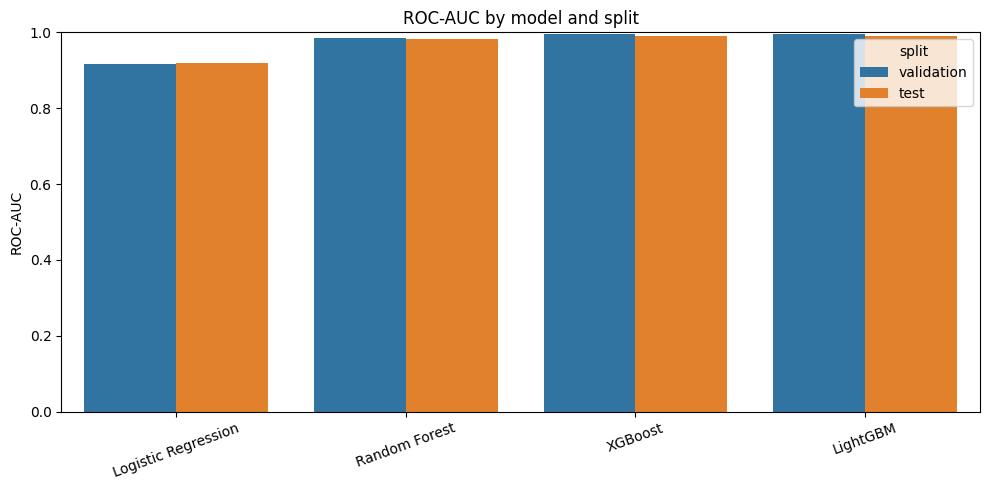

In [6]:
comparison = pd.concat(
    [evaluate_pipeline(model_name, pipeline, threshold=0.50) for model_name, pipeline in best_pipelines.items()],
    ignore_index=True,
)
comparison.to_csv(TABLE_DIR / "model_comparison.csv", index=False)
comparison.to_csv(ROOT / "reports" / "model_comparison.csv", index=False)

validation_comparison = (
    comparison[comparison["split"] == "validation"]
    .sort_values(["roc_auc", "f1_churn", "recall_churn"], ascending=False)
    .reset_index(drop=True)
)
selected_model_name = validation_comparison.iloc[0]["model"]
selected_pipeline = best_pipelines[selected_model_name]

print(f"Selected model by validation ROC-AUC: {selected_model_name}")
display(comparison.sort_values(["split", "roc_auc"], ascending=[True, False]))
display(validation_comparison)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(
    data=comparison[comparison["split"].isin(["validation", "test"])],
    x="model",
    y="roc_auc",
    hue="split",
    ax=ax,
)
ax.set_title("ROC-AUC by model and split")
ax.set_ylim(0.0, 1.0)
ax.set_xlabel("")
ax.set_ylabel("ROC-AUC")
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
fig.savefig(FIG_DIR / "model_metric_comparison.png", bbox_inches="tight")
fig.savefig(ROOT / "reports" / "model_metric_comparison.png", bbox_inches="tight")
plt.show()

## 7. Threshold Selection

The selected threshold is chosen on validation predictions only. Among thresholds that meet the target churn recall, the notebook chooses the one with the best F1 and then precision. The test set remains untouched until the final report below.

Selected threshold: 0.52


,threshold,precision_churn,recall_churn,f1_churn,predicted_churn_rate,selected
47,0.52,0.914634,0.922131,0.918367,0.161949,True
48,0.53,0.914286,0.918033,0.916155,0.161290,False
49,0.54,0.914286,0.918033,0.916155,0.161290,False
60,0.65,0.939655,0.893443,0.915966,0.152732,False
61,0.66,0.939655,0.893443,0.915966,0.152732,False
62,0.67,0.939655,0.893443,0.915966,0.152732,False
50,0.55,0.917695,0.913934,0.915811,0.159974,False
51,0.56,0.917695,0.913934,0.915811,0.159974,False
52,0.57,0.921162,0.909836,0.915464,0.158657,False
78,0.83,0.976744,0.860656,0.915033,0.141540,False


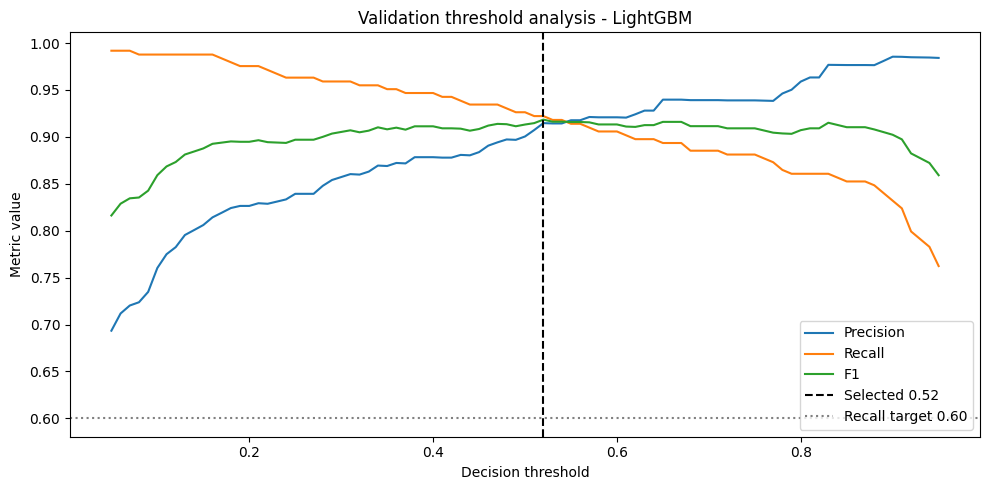

In [7]:
valid_prob = positive_class_proba(selected_pipeline, X_valid)
thresholds = threshold_table(y_valid, valid_prob)
selected_threshold = choose_threshold(thresholds, TARGET_RECALL)
thresholds["selected"] = thresholds["threshold"].eq(selected_threshold)
thresholds.to_csv(TABLE_DIR / "threshold_analysis.csv", index=False)
thresholds.to_csv(ROOT / "reports" / "threshold_analysis.csv", index=False)

print(f"Selected threshold: {selected_threshold:.2f}")
display(thresholds.sort_values(["selected", "f1_churn"], ascending=[False, False]).head(10))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresholds["threshold"], thresholds["precision_churn"], label="Precision")
ax.plot(thresholds["threshold"], thresholds["recall_churn"], label="Recall")
ax.plot(thresholds["threshold"], thresholds["f1_churn"], label="F1")
ax.axvline(selected_threshold, color="black", linestyle="--", label=f"Selected {selected_threshold:.2f}")
ax.axhline(TARGET_RECALL, color="gray", linestyle=":", label=f"Recall target {TARGET_RECALL:.2f}")
ax.set_title(f"Validation threshold analysis - {selected_model_name}")
ax.set_xlabel("Decision threshold")
ax.set_ylabel("Metric value")
ax.legend()
plt.tight_layout()
fig.savefig(FIG_DIR / "threshold_analysis.png", bbox_inches="tight")
fig.savefig(ROOT / "reports" / "threshold_analysis.png", bbox_inches="tight")
plt.show()

## 8. Final Holdout Evaluation And Prediction Exports

The final test metrics are reported once using the selected model and selected validation threshold. Prediction files include the client identifier for traceability, but the identifier is not used as a model feature.

In [8]:
def prediction_export(ids: pd.Series, y_true: pd.Series, y_prob: np.ndarray, threshold: float) -> pd.DataFrame:
    y_pred = (y_prob >= threshold).astype(int)
    return pd.DataFrame(
        {
            ID_COL: ids.to_numpy(),
            "actual_churn": y_true.to_numpy(),
            "predicted_churn_probability": y_prob,
            "selected_threshold": threshold,
            "predicted_churn": y_pred,
        }
    )

valid_predictions = prediction_export(ids_valid, y_valid, valid_prob, selected_threshold)
test_prob = positive_class_proba(selected_pipeline, X_test)
test_predictions = prediction_export(ids_test, y_test, test_prob, selected_threshold)

valid_predictions.to_csv(PRED_DIR / "validation_predictions.csv", index=False)
test_predictions.to_csv(PRED_DIR / "test_predictions.csv", index=False)

final_metrics = pd.DataFrame(
    [
        metric_row(selected_model_name, "validation", y_valid, valid_prob, selected_threshold),
        metric_row(selected_model_name, "test", y_test, test_prob, selected_threshold),
    ]
)
final_metrics.to_csv(TABLE_DIR / "final_model_metrics.csv", index=False)
final_metrics.to_csv(ROOT / "reports" / "final_model_metrics.csv", index=False)

print("Final model:", selected_model_name)
print(f"Final threshold: {selected_threshold:.2f}")
display(final_metrics)

print("Test classification report:")
print(classification_report(y_test, (test_prob >= selected_threshold).astype(int), target_names=["Existing", "Attrited"], zero_division=0))
print("Test confusion matrix:")
print(confusion_matrix(y_test, (test_prob >= selected_threshold).astype(int)))

Final model: LightGBM
Final threshold: 0.52


,model,split,threshold,roc_auc,accuracy,precision_churn,recall_churn,f1_churn
0,LightGBM,validation,0.52,0.995358,0.973667,0.914634,0.922131,0.918367
1,LightGBM,test,0.52,0.991100,0.963816,0.879518,0.897541,0.888438


Test classification report:
              precision    recall  f1-score   support

    Existing       0.98      0.98      0.98      1276
    Attrited       0.88      0.90      0.89       244

    accuracy                           0.96      1520
   macro avg       0.93      0.94      0.93      1520
weighted avg       0.96      0.96      0.96      1520

Test confusion matrix:
[[1246   30]
 [  25  219]]


## 9. Final Model Interpretation

Feature importance is reported for the selected fitted pipeline. Tree models use native `feature_importances_`; Logistic Regression uses absolute coefficient size. These are predictive associations, not causal effects.

,feature,importance_pct,importance,importance_type
0,Total_Trans_Amt,22.964899,615,native_importance
1,Total_Amt_Chng_Q4_Q1,12.098581,324,native_importance
2,Total_Trans_Ct,11.463779,307,native_importance
3,Total_Ct_Chng_Q4_Q1,8.513816,228,native_importance
4,Total_Revolving_Bal,6.833458,183,native_importance
5,Customer_Age,6.273338,168,native_importance
6,Avg_Open_To_Buy,4.966393,133,native_importance
7,Total_Relationship_Count,4.817028,129,native_importance
8,Credit_Limit,4.742345,127,native_importance
9,Months_on_book,3.659447,98,native_importance


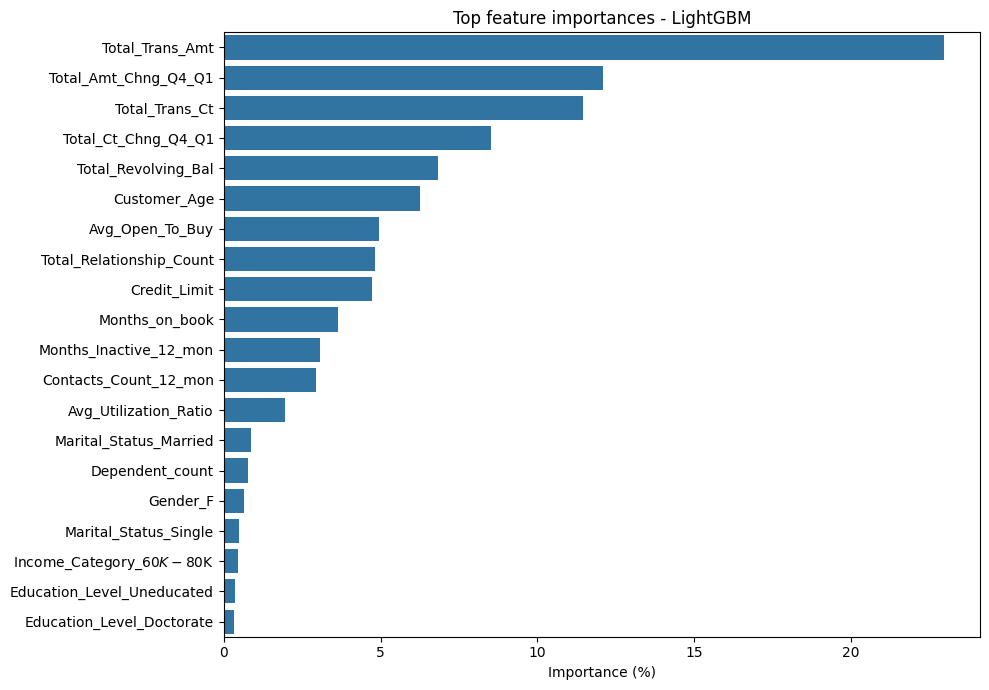

In [9]:
def feature_importance_frame(pipeline: Pipeline, model_name: str) -> pd.DataFrame:
    feature_names = pipeline.named_steps["preprocess"].get_feature_names_out()
    model = pipeline.named_steps["model"]
    if hasattr(model, "feature_importances_"):
        importances = model.feature_importances_
        importance_type = "native_importance"
    elif hasattr(model, "coef_"):
        importances = np.abs(model.coef_).ravel()
        importance_type = "absolute_coefficient"
    else:
        raise ValueError(f"No feature importance available for {model_name}")

    importance_df = pd.DataFrame(
        {"feature": feature_names, "importance": importances, "importance_type": importance_type}
    )
    total_importance = importance_df["importance"].sum()
    importance_df["importance_pct"] = np.where(
        total_importance > 0,
        importance_df["importance"] / total_importance * 100,
        0.0,
    )
    return importance_df.sort_values("importance", ascending=False).reset_index(drop=True)

feature_importance = feature_importance_frame(selected_pipeline, selected_model_name)
feature_importance.to_csv(TABLE_DIR / "final_model_feature_importance.csv", index=False)
feature_importance.to_csv(ROOT / "reports" / "final_model_feature_importance.csv", index=False)

top_features = feature_importance.head(20)
display(top_features[["feature", "importance_pct", "importance", "importance_type"]])

fig, ax = plt.subplots(figsize=(10, 7))
sns.barplot(data=top_features, x="importance_pct", y="feature", ax=ax)
ax.set_title(f"Top feature importances - {selected_model_name}")
ax.set_xlabel("Importance (%)")
ax.set_ylabel("")
plt.tight_layout()
fig.savefig(FIG_DIR / "final_model_feature_importance.png", bbox_inches="tight")
fig.savefig(ROOT / "reports" / "final_model_feature_importance.png", bbox_inches="tight")
plt.show()

## 10. Save Pipeline, Metadata, And Inference Contract

The saved artifact is a complete scikit-learn `Pipeline`, including preprocessing and the selected model. Downstream inference should provide the same feature columns listed below; the pipeline handles numeric imputation, scaling, categorical imputation, one-hot encoding, and prediction.

In [10]:
model_path = MODEL_DIR / "churn_model_pipeline.joblib"
metadata_path = MODEL_DIR / "churn_model_metadata.json"
joblib.dump(selected_pipeline, model_path)

metadata = {
    "model_name": selected_model_name,
    "selected_threshold": selected_threshold,
    "target_mapping": {"Existing Customer": 0, "Attrited Customer": 1},
    "random_seed": RANDOM_SEED,
    "n_optuna_trials_per_model": N_TRIALS,
    "features": FEATURES,
    "numeric_features": NUMERIC_FEATURES,
    "categorical_features": CATEGORICAL_FEATURES,
    "excluded_columns": LEAKAGE_COLS,
    "preprocessing": {
        "numeric": "median imputation + standard scaling",
        "categorical": "most frequent imputation + one-hot encoding with unknown categories ignored at inference",
    },
    "inference_contract": {
        "input_columns_required": FEATURES,
        "input_columns_not_used": [TARGET] + LEAKAGE_COLS,
        "output_probability_name": "predicted_churn_probability",
        "thresholded_output_name": "predicted_churn",
    },
    "validation_metrics_at_selected_threshold": final_metrics[final_metrics["split"] == "validation"].iloc[0].to_dict(),
    "test_metrics_at_selected_threshold": final_metrics[final_metrics["split"] == "test"].iloc[0].to_dict(),
    "package_versions": {
        "python": platform.python_version(),
        "pandas": pd.__version__,
        "numpy": np.__version__,
        "scikit_learn": sklearn.__version__,
        "xgboost": xgb.__version__,
        "lightgbm": lgb.__version__,
        "optuna": optuna.__version__,
    },
}

with metadata_path.open("w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2)

model_card = pd.DataFrame(
    [
        {"item": "final_model", "value": selected_model_name},
        {"item": "selected_threshold", "value": f"{selected_threshold:.2f}"},
        {"item": "selection_metric", "value": "validation ROC-AUC"},
        {"item": "threshold_rule", "value": f"best validation F1 among thresholds with recall >= {TARGET_RECALL:.2f}"},
        {"item": "leakage_exclusions", "value": ", ".join(LEAKAGE_COLS)},
        {"item": "saved_pipeline", "value": str(model_path.relative_to(ROOT))},
    ]
)
model_card.to_csv(TABLE_DIR / "final_model_card.csv", index=False)
model_card.to_csv(ROOT / "reports" / "final_model_card.csv", index=False)

display(model_card)
print(f"Saved pipeline: {model_path}")
print(f"Saved metadata: {metadata_path}")

,item,value
0,final_model,LightGBM
1,selected_threshold,0.52
2,selection_metric,validation ROC-AUC
3,threshold_rule,best validation F1 among thresholds with recal...
4,leakage_exclusions,"CLIENTNUM, Naive_Bayes_Classifier_Attrition_Fl..."
5,saved_pipeline,artifacts\models\churn_model_pipeline.joblib


Saved pipeline: c:\Users\Windows\Documents\Personal\bank-churners\artifacts\models\churn_model_pipeline.joblib
Saved metadata: c:\Users\Windows\Documents\Personal\bank-churners\artifacts\models\churn_model_metadata.json


## 11. Final Decision And Limitations

The final model is selected by validation ROC-AUC, with train/test comparisons reviewed for overfitting. The selected threshold is chosen on validation data to prioritize churn recall while keeping F1 reasonable.

Limitations:

- This model uses historical behavioral and account variables, so results are predictive associations rather than causal explanations.
- `Unknown` categories are retained as explicit values; their business meaning should be reviewed before operational use.
- The test set is a static holdout from the same dataset. Future performance should be monitored on newer customer cohorts.
- Threshold choice reflects the stated recall target; a different business cost ratio for false positives vs false negatives could justify a different threshold.